# APPL


## Imports


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Layer, Input, Embedding, LSTM, Bidirectional, SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score 
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [ ]:
dataset = load_data('AAPL_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [ ]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [ ]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.3)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.2)(x)

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)
        
x_attn = AttnPool()(x)
x_max  = GlobalMaxPooling1D()(x)
x = Concatenate()([x_attn, x_max])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr', 
        mode='max',
        patience=5, 
        restore_best_weights=True, 
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr', 
        mode='max',
        factor=0.5, 
        patience=2, 
        min_lr=1e-6, 
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_aapl.keras',
        monitor='val_auc_pr', 
        mode='max', 
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
# Binary focal loss with class balancing (alpha), gamma focuses on hard examples
def binary_focal_loss(alpha=0.75, gamma=2.0):
    # alpha is weight for class 1 (bullish). 0.75 => up-weight bullish; use 0.25 if
    # you want to up-weight bearish (your minority).
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        a_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return -tf.reduce_mean(a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t))
    return loss


model.compile(
    optimizer=optimizer, 
    loss=binary_focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)
             
history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

## Calibrated metrics (second-stage threshold tuning)


In [ ]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
best = (-1, None)
for t in np.linspace(0.2, 0.8, 121):
    y_pred_t = (p_bull >= t).astype(int)
    f1_neg = f1_score(y_true, y_pred_t, pos_label=0, zero_division=0)
    if f1_neg > best[0]:
        best = (f1_neg, t)
best_t = best[1]
y_pred = (p_bull >= best_t).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Best threshold:  {best_t:.3f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

## Loss curve


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
tf.keras.backend.clear_session()

# AMZN


## Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Layer, Input, Embedding, LSTM, Bidirectional, SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score 
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [3]:
dataset = load_data('AMZN_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

dataset['body_clean'] = dataset['body_clean'].fillna('').astype(str)

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [4]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [5]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.3)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.2)(x)

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)
        
x_attn = AttnPool()(x)
x_max  = GlobalMaxPooling1D()(x)
x = Concatenate()([x_attn, x_max])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 19)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 19, 100)      2000000     ['input_1[0][0]']                
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 19, 100)     0           ['embedding[0][0]']              
 out1D)                                                                                           
                                                                                                  
 conv1d (Conv1D)     

## Set up callbacks and model


In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr', 
        mode='max',
        patience=5, 
        restore_best_weights=True, 
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr', 
        mode='max',
        factor=0.5, 
        patience=2, 
        min_lr=1e-6, 
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_amzn.keras',
        monitor='val_auc_pr', 
        mode='max', 
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
# Binary focal loss with class balancing (alpha), gamma focuses on hard examples
def binary_focal_loss(alpha=0.75, gamma=2.0):
    # alpha is weight for class 1 (bullish). 0.75 => up-weight bullish; use 0.25 if
    # you want to up-weight bearish (your minority).
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        a_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return -tf.reduce_mean(a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t))
    return loss


model.compile(
    optimizer=optimizer, 
    loss=binary_focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)
             
history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

Epoch 1/25
2645/2645 [==============================] - 33s 10ms/step - loss: 0.0645 - auc: 0.8646 - auc_pr: 0.8212 - recall: 0.5721 - precision: 0.8199 - val_loss: 0.0486 - val_auc: 0.9267 - val_auc_pr: 0.9108 - val_recall: 0.6560 - val_precision: 0.8913 - lr: 3.0000e-04
Epoch 2/25
2645/2645 [==============================] - 25s 9ms/step - loss: 0.0441 - auc: 0.9255 - auc_pr: 0.9094 - recall: 0.6831 - precision: 0.8859 - val_loss: 0.0370 - val_auc: 0.9436 - val_auc_pr: 0.9339 - val_recall: 0.7582 - val_precision: 0.8982 - lr: 3.0000e-04
Epoch 3/25
2645/2645 [==============================] - 25s 9ms/step - loss: 0.0361 - auc: 0.9409 - auc_pr: 0.9301 - recall: 0.7270 - precision: 0.9034 - val_loss: 0.0328 - val_auc: 0.9496 - val_auc_pr: 0.9416 - val_recall: 0.7442 - val_precision: 0.9124 - lr: 3.0000e-04
Epoch 4/25
2645/2645 [==============================] - 25s 9ms/step - loss: 0.0325 - auc: 0.9487 - auc_pr: 0.9407 - recall: 0.7457 - precision: 0.9116 - val_loss: 0.0314 - val_auc: 0

## Calibrated metrics (second-stage threshold tuning)


In [7]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
best = (-1, None)
for t in np.linspace(0.2, 0.8, 121):
    y_pred_t = (p_bull >= t).astype(int)
    f1_neg = f1_score(y_true, y_pred_t, pos_label=0, zero_division=0)
    if f1_neg > best[0]:
        best = (f1_neg, t)
best_t = best[1]
y_pred = (p_bull >= best_t).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Best threshold:  {best_t:.3f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

Best threshold:  0.425
Accuracy:        0.9038
Precision macro: 0.9053 | weighted: 0.9053
Recall macro:    0.9038 | weighted: 0.9038
F1 macro:        0.9037 | weighted: 0.9037

[[16413  2381]
 [ 1237 17578]]
              precision    recall  f1-score   support

           0     0.9299    0.8733    0.9007     18794
           1     0.8807    0.9343    0.9067     18815

    accuracy                         0.9038     37609
   macro avg     0.9053    0.9038    0.9037     37609
weighted avg     0.9053    0.9038    0.9037     37609



## Loss curve


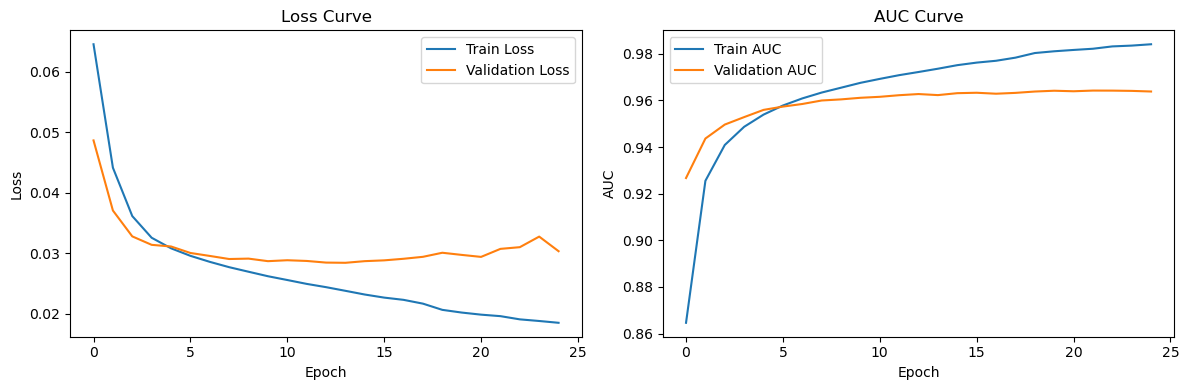

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
tf.keras.backend.clear_session()

# FB


## Imports


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Layer, Input, Embedding, LSTM, Bidirectional, SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score 
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [ ]:
dataset = load_data('FB_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [ ]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [ ]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.3)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.2)(x)

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)
        
x_attn = AttnPool()(x)
x_max  = GlobalMaxPooling1D()(x)
x = Concatenate()([x_attn, x_max])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr', 
        mode='max',
        patience=5, 
        restore_best_weights=True, 
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr', 
        mode='max',
        factor=0.5, 
        patience=2, 
        min_lr=1e-6, 
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_fb.keras',
        monitor='val_auc_pr', 
        mode='max', 
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
# Binary focal loss with class balancing (alpha), gamma focuses on hard examples
def binary_focal_loss(alpha=0.75, gamma=2.0):
    # alpha is weight for class 1 (bullish). 0.75 => up-weight bullish; use 0.25 if
    # you want to up-weight bearish (your minority).
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        a_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return -tf.reduce_mean(a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t))
    return loss


model.compile(
    optimizer=optimizer, 
    loss=binary_focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)
             
history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

## Calibrated metrics (second-stage threshold tuning)


In [ ]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
best = (-1, None)
for t in np.linspace(0.2, 0.8, 121):
    y_pred_t = (p_bull >= t).astype(int)
    f1_neg = f1_score(y_true, y_pred_t, pos_label=0, zero_division=0)
    if f1_neg > best[0]:
        best = (f1_neg, t)
best_t = best[1]
y_pred = (p_bull >= best_t).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Best threshold:  {best_t:.3f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

## Loss curve


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
tf.keras.backend.clear_session()

# NVDA


## Imports


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Layer, Input, Embedding, LSTM, Bidirectional, SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score 
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [ ]:
dataset = load_data('NVDA_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [ ]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [ ]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.3)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.2)(x)

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)
        
x_attn = AttnPool()(x)
x_max  = GlobalMaxPooling1D()(x)
x = Concatenate()([x_attn, x_max])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr', 
        mode='max',
        patience=5, 
        restore_best_weights=True, 
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr', 
        mode='max',
        factor=0.5, 
        patience=2, 
        min_lr=1e-6, 
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_nvda.keras',
        monitor='val_auc_pr', 
        mode='max', 
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
# Binary focal loss with class balancing (alpha), gamma focuses on hard examples
def binary_focal_loss(alpha=0.75, gamma=2.0):
    # alpha is weight for class 1 (bullish). 0.75 => up-weight bullish; use 0.25 if
    # you want to up-weight bearish (your minority).
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        a_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return -tf.reduce_mean(a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t))
    return loss


model.compile(
    optimizer=optimizer, 
    loss=binary_focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)
             
history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

## Calibrated metrics (second-stage threshold tuning)


In [ ]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
best = (-1, None)
for t in np.linspace(0.2, 0.8, 121):
    y_pred_t = (p_bull >= t).astype(int)
    f1_neg = f1_score(y_true, y_pred_t, pos_label=0, zero_division=0)
    if f1_neg > best[0]:
        best = (f1_neg, t)
best_t = best[1]
y_pred = (p_bull >= best_t).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Best threshold:  {best_t:.3f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

## Loss curve


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
tf.keras.backend.clear_session()

# TSLA


## Imports


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Layer, Input, Embedding, LSTM, Bidirectional, SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score 
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [ ]:
dataset = load_data('TSLA_final.csv', columns=['body_clean', 'entities'])

# Ensure labels are numeric (robust to strings/missing values)
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Force text to string (prevents Tokenizer from seeing floats/NaN)
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [ ]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [ ]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.3)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.2)(x)

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)
        
x_attn = AttnPool()(x)
x_max  = GlobalMaxPooling1D()(x)
x = Concatenate()([x_attn, x_max])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr', 
        mode='max',
        patience=5, 
        restore_best_weights=True, 
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr', 
        mode='max',
        factor=0.5, 
        patience=2, 
        min_lr=1e-6, 
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_tsla.keras',
        monitor='val_auc_pr', 
        mode='max', 
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
# Binary focal loss with class balancing (alpha), gamma focuses on hard examples
def binary_focal_loss(alpha=0.75, gamma=2.0):
    # alpha is weight for class 1 (bullish). 0.75 => up-weight bullish; use 0.25 if
    # you want to up-weight bearish (your minority).
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        a_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return -tf.reduce_mean(a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t))
    return loss


model.compile(
    optimizer=optimizer, 
    loss=binary_focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)
             
history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

## Calibrated metrics (second-stage threshold tuning)


In [ ]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
best = (-1, None)
for t in np.linspace(0.2, 0.8, 121):
    y_pred_t = (p_bull >= t).astype(int)
    f1_neg = f1_score(y_true, y_pred_t, pos_label=0, zero_division=0)
    if f1_neg > best[0]:
        best = (f1_neg, t)
best_t = best[1]
y_pred = (p_bull >= best_t).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Best threshold:  {best_t:.3f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

## Loss curve


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
tf.keras.backend.clear_session()